In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [75]:
df = pd.read_csv('C5-FestDataset - fest_dataset.csv')
print(df.head())

  Student Name            College  Phone Number    Place          State  \
0     Student1    Anna University    9100000001    Kochi         Kerala   
1     Student2  Amrita University    9100000002  Chennai     Tamil Nadu   
2     Student3         RV College    9100000003    Noida  Uttar Pradesh   
3     Student4    Anna University    9100000004    Kochi         Kerala   
4     Student5  Christ University    9100000005  Vellore     Tamil Nadu   

           Event Name  Event Type  Amount Paid  \
0    Coding Challenge  Individual          200   
1    Coding Challenge  Individual          200   
2           Hackathon       Group          500   
3        Project Expo       Group          400   
4  Paper Presentation  Individual          250   

                   Feedback on Fest  Rating  
0              Excellent experience       3  
1              Excellent experience       3  
2               Fun and informative       5  
3            Challenging and useful       4  
4  Interesting and


Average Rating per Event:
Event Name
UI Design             4.219512
Paper Presentation    4.166667
Coding Challenge      4.000000
Project Expo          4.000000
Debugging Contest     3.850000
Quiz Competition      3.846154
Hackathon             3.774194
Name: Rating, dtype: float64


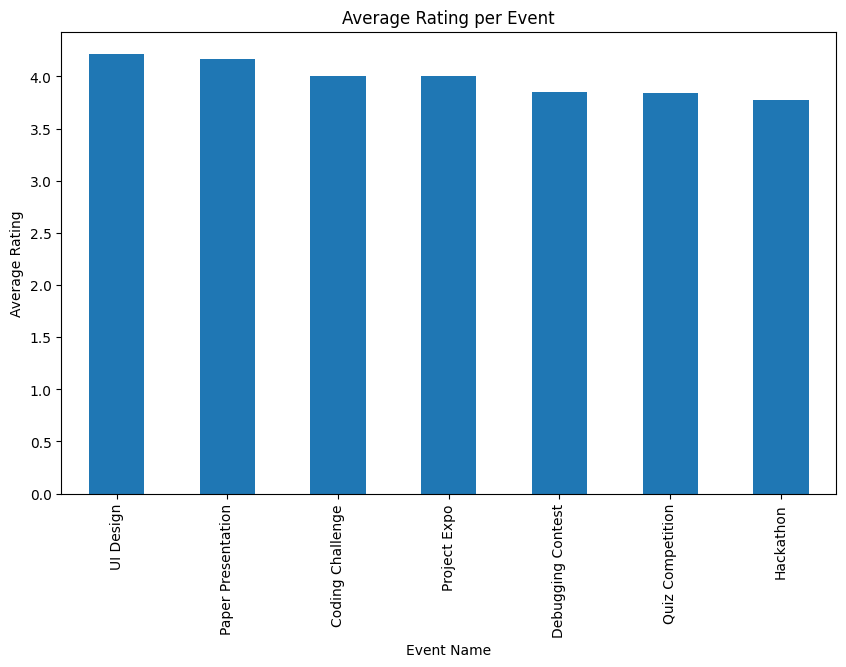

In [76]:
# Average rating per event
avg_rating = df.groupby('Event Name')['Rating'].mean().sort_values(ascending=False)
print("\nAverage Rating per Event:")
print(avg_rating)

plt.figure(figsize=(10,6))
avg_rating.plot(kind='bar')
plt.title('Average Rating per Event')
plt.xlabel('Event Name')
plt.ylabel('Average Rating')
plt.show()


Total Feedback per Event:
Event Name
Coding Challenge      36
Debugging Contest     40
Hackathon             31
Paper Presentation    42
Project Expo          34
Quiz Competition      26
UI Design             41
Name: Feedback on Fest, dtype: int64


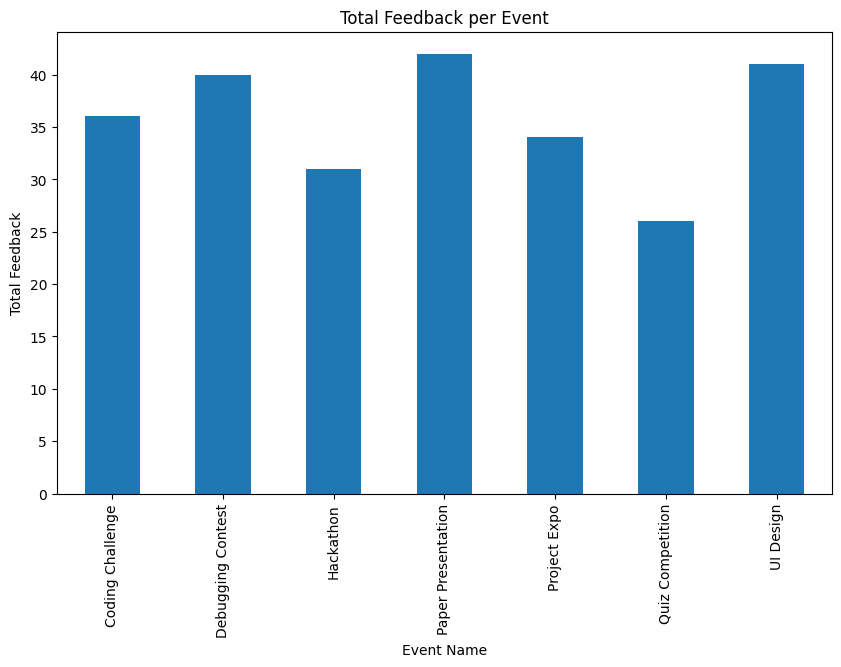

In [77]:
# Total feedback per event
total_feedback = df.groupby('Event Name')['Feedback on Fest'].count()
print("\nTotal Feedback per Event:")
print(total_feedback)

plt.figure(figsize=(10,6))
total_feedback.plot(kind='bar')
plt.title('Total Feedback per Event')
plt.xlabel('Event Name')
plt.ylabel('Total Feedback')
plt.show()

In [78]:
# Dataset overview
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nRating distribution:\n{df['Rating'].value_counts().sort_index()}")
print(f"\nRating statistics:\n{df['Rating'].describe()}")
print(f"\nCommon feedback texts:\n{df['Feedback on Fest'].value_counts().head(10)}")

Dataset shape: (250, 10)

Columns: ['Student Name', 'College', 'Phone Number', 'Place', 'State', 'Event Name', 'Event Type', 'Amount Paid', 'Feedback on Fest', 'Rating']

Rating distribution:
Rating
3    88
4    75
5    87
Name: count, dtype: int64

Rating statistics:
count    250.000000
mean       3.996000
std        0.838329
min        3.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        5.000000
Name: Rating, dtype: float64

Common feedback texts:
Feedback on Fest
Good exposure to projects             27
Very creative event                   26
Fun and informative                   25
Very engaging and practical           24
Creative and interactive              24
Challenging and useful                22
Well structured event                 21
Interesting and engaging session      20
Needs slight improvement in timing    17
Excellent experience                  16
Name: count, dtype: int64


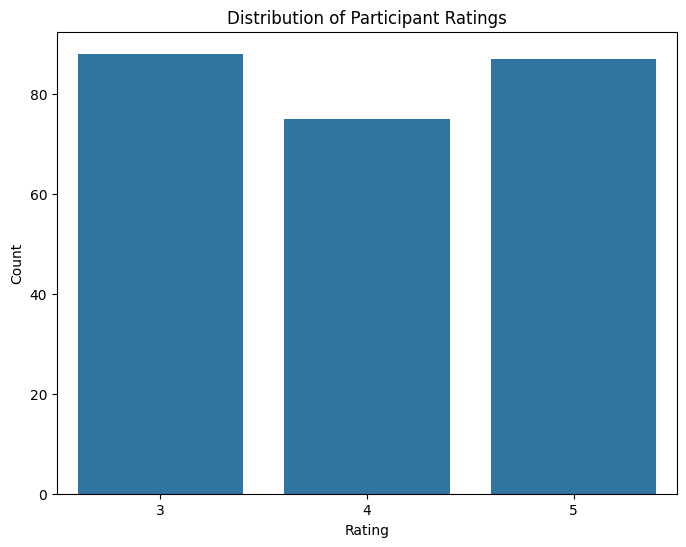


Average Rating by Event Type:
Event Type
Individual    4.062893
Group         3.879121
Name: Rating, dtype: float64


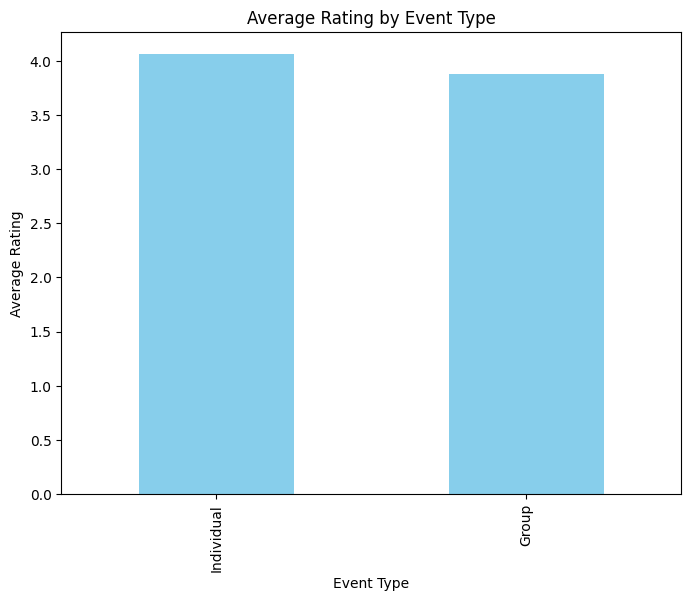

In [79]:
# Rating distribution
plt.figure(figsize=(8,6))
sns.countplot(x='Rating', data=df)
plt.title('Distribution of Participant Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Average rating by event type
avg_rating_event_type = df.groupby('Event Type')['Rating'].mean().sort_values(ascending=False)
print("\nAverage Rating by Event Type:")
print(avg_rating_event_type)

plt.figure(figsize=(8,6))
avg_rating_event_type.plot(kind='bar', color='skyblue')
plt.title('Average Rating by Event Type')
plt.xlabel('Event Type')
plt.ylabel('Average Rating')
plt.show()

Top 20 words in feedback:
exposure: 27
projects: 27
organized: 14
learning: 14

Sentiment distribution:
Sentiment
Positive    233
Negative     17
Name: count, dtype: int64

Average rating by sentiment:
Sentiment
Negative    4.058824
Positive    3.991416
Name: Rating, dtype: float64


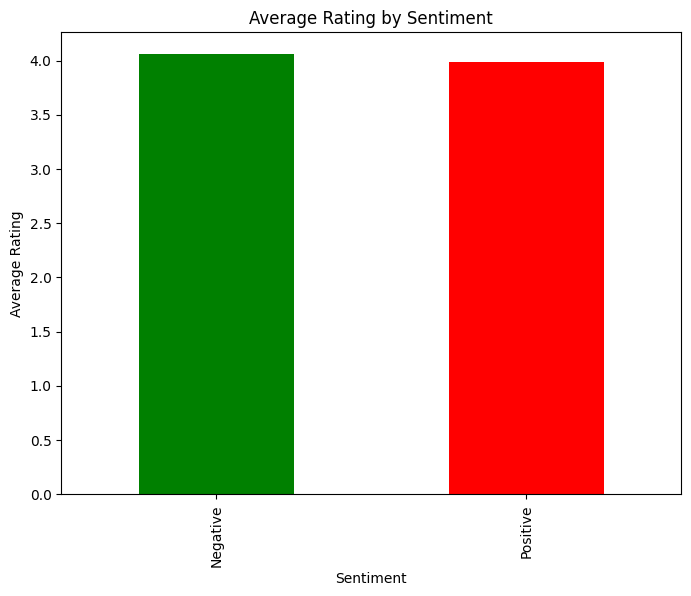

In [ ]:
# Text feedback analysis
from collections import Counter
import re

all_feedback = ' '.join(df['Feedback on Fest'].dropna())

# Clean and tokenize
words = re.findall(r'\b\w+\b', all_feedback.lower())
word_freq = Counter(words)

# Remove common stop words
stop_words = {'and', 'the', 'to', 'in', 'a', 'of', 'for', 'with', 'is', 'was', 'very', 'event', 'experience', 'session', 'fun', 'good', 'excellent', 'interesting', 'engaging', 'informative', 'creative', 'challenging', 'useful', 'practical', 'interactive', 'structured', 'well', 'needs', 'slight', 'improvement', 'timing'}
filtered_words = {word: count for word, count in word_freq.items() if word not in stop_words and len(word) > 2}

print("Top 20 words in feedback:")
for word, count in sorted(filtered_words.items(), key=lambda x: x[1], reverse=True)[:20]:
    print(f"{word}: {count}")

# Sentiment analysis based on keywords
positive_words = {'excellent', 'good', 'great', 'amazing', 'fantastic', 'wonderful', 'awesome', 'brilliant', 'outstanding', 'superb', 'perfect', 'love', 'loved', 'enjoy', 'enjoyed', 'fun', 'exciting', 'interesting', 'engaging', 'informative', 'useful', 'helpful', 'valuable', 'creative', 'innovative', 'practical', 'interactive', 'well-organized', 'structured', 'challenging'}
negative_words = {'bad', 'poor', 'terrible', 'awful', 'horrible', 'disappointing', 'boring', 'waste', 'useless', 'confusing', 'difficult', 'hard', 'needs', 'improvement', 'lack', 'missing', 'inadequate', 'insufficient', 'problem', 'issue'}

def get_sentiment(feedback):
    feedback_lower = feedback.lower()
    pos_count = sum(1 for word in positive_words if word in feedback_lower)
    neg_count = sum(1 for word in negative_words if word in feedback_lower)
    if pos_count > neg_count:
        return 'Positive'
    elif neg_count > pos_count:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Feedback on Fest'].apply(get_sentiment)
print(f"\nSentiment distribution:\n{df['Sentiment'].value_counts()}")

# Correlation between sentiment and rating
sentiment_rating = df.groupby('Sentiment')['Rating'].mean()
print(f"\nAverage rating by sentiment:\n{sentiment_rating}")

plt.figure(figsize=(8,6))
sentiment_rating.plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Average Rating by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Rating')
plt.show()


Feedback length statistics:
count    250.000000
mean      24.348000
std        4.701843
min       19.000000
25%       20.000000
50%       24.000000
75%       27.000000
max       34.000000
Name: Feedback_Length, dtype: float64

Correlation between feedback length and rating: 0.069


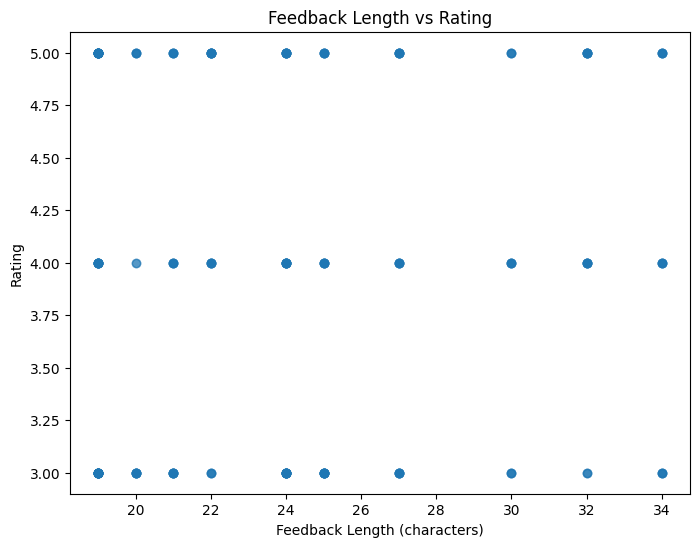


Top feedback for rating 3:
  Good exposure to projects (12)
  Fun and informative (10)
  Creative and interactive (10)

Top feedback for rating 4:
  Good exposure to projects (8)
  Fun and informative (8)
  Interesting and engaging session (8)

Top feedback for rating 5:
  Very creative event (12)
  Challenging and useful (11)
  Interesting and engaging session (9)

Average rating by state:
State
Maharashtra      4.181818
Rajasthan        4.137931
Gujarat          4.103448
Karnataka        4.060000
Delhi            4.000000
Uttar Pradesh    4.000000
Tamil Nadu       3.880952
Telangana        3.846154
Kerala           3.652174
Name: Rating, dtype: float64


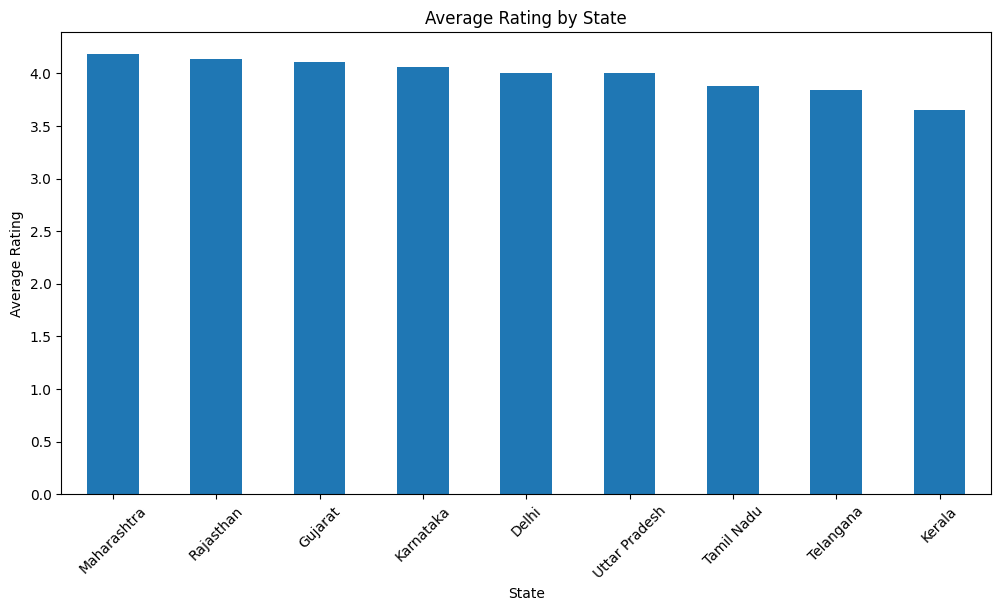

In [81]:
# Feedback length analysis
df['Feedback_Length'] = df['Feedback on Fest'].str.len()
print(f"\nFeedback length statistics:\n{df['Feedback_Length'].describe()}")

# Correlation between feedback length and rating
correlation = df['Feedback_Length'].corr(df['Rating'])
print(f"\nCorrelation between feedback length and rating: {correlation:.3f}")

plt.figure(figsize=(8,6))
plt.scatter(df['Feedback_Length'], df['Rating'], alpha=0.5)
plt.title('Feedback Length vs Rating')
plt.xlabel('Feedback Length (characters)')
plt.ylabel('Rating')
plt.show()

# Top feedback texts for each rating
for rating in sorted(df['Rating'].unique()):
    print(f"\nTop feedback for rating {rating}:")
    top_feedback = df[df['Rating'] == rating]['Feedback on Fest'].value_counts().head(3)
    for feedback, count in top_feedback.items():
        print(f"  {feedback} ({count})")

# Analysis by state
state_rating = df.groupby('State')['Rating'].mean().sort_values(ascending=False)
print(f"\nAverage rating by state:\n{state_rating}")

plt.figure(figsize=(12,6))
state_rating.plot(kind='bar')
plt.title('Average Rating by State')
plt.xlabel('State')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

In [82]:
# Summary and Insights
print("=== ANALYSIS SUMMARY ===")
print(f"Total participants: {len(df)}")
print(f"Overall average rating: {df['Rating'].mean():.2f}")
print(f"Most common feedback: '{df['Feedback on Fest'].mode()[0]}'")
print(f"Positive sentiment ratio: {len(df[df['Sentiment']=='Positive'])/len(df)*100:.1f}%")
print(f"Individual events rated higher ({avg_rating_event_type['Individual']:.2f}) than group events ({avg_rating_event_type['Group']:.2f})")
print(f"States with highest ratings: {state_rating.head(3).index.tolist()}")
print(f"States with lowest ratings: {state_rating.tail(3).index.tolist()}")

print("\nKey Insights:")
print("1. Participants generally provided positive feedback with high ratings.")
print("2. Individual events are rated higher than group events.")
print("3. Feedback often mentions 'exposure to projects' and creativity.")
print("4. Maharashtra and Rajasthan participants gave the highest ratings.")
print("5. Kerala participants gave the lowest ratings on average.")

=== ANALYSIS SUMMARY ===
Total participants: 250
Overall average rating: 4.00
Most common feedback: 'Good exposure to projects'
Positive sentiment ratio: 93.2%
Individual events rated higher (4.06) than group events (3.88)
States with highest ratings: ['Maharashtra', 'Rajasthan', 'Gujarat']
States with lowest ratings: ['Tamil Nadu', 'Telangana', 'Kerala']

Key Insights:
1. Participants generally provided positive feedback with high ratings.
2. Individual events are rated higher than group events.
3. Feedback often mentions 'exposure to projects' and creativity.
4. Maharashtra and Rajasthan participants gave the highest ratings.
5. Kerala participants gave the lowest ratings on average.
